In [3]:
import shap

c:\Anaconda\envs\gemastik2024\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import pandas as pd

train_df = pd.read_csv('spacecraft_train_preprocessed.csv')

In [5]:
from sklearn.preprocessing import LabelEncoder

# Initialize the label encoder
label_encoder = LabelEncoder()

# Fit and transform the 'race' column to convert categories to numbers
train_df['race'] = label_encoder.fit_transform(train_df['race'])


In [6]:
train_df

tournament  game_length  winner  max_collection_rate  apm   spm  \
0            0.0          848       0                 3778  316  26.3   
1            1.0          612       1                 4344  398  42.9   
2            1.0          486       0                 3095  389  35.9   
3            0.0         1078       0                 4064  449  40.2   
4            2.0         1001       1                 4484  627  37.6   
...          ...          ...     ...                  ...  ...   ...   
1653         2.0         1059       0                 3471  415  33.9   
1654         1.0          473       0                 2625  410  16.5   
1655         1.0          650       1                 3510  335  45.0   
1656         0.0          881       0                 3862  379  45.5   
1657         1.0          447       1                 2311  296  45.5   

      workers_produced  workers_killed  workers_lost  supply_block  ...  \
0                   75              18            17            75  ...   
1                   97              22            21            30  ...   
2                   80              11            17            20  ...   
3                   77              68            30            15  ...   
4                   98              24            25            25  ...   
...                ...             ...           ...           ...  ...   
1653                89              54            51            45  ...   
1654                49               3             4            20  ...   
1655                66               7             3             5  ...   
1656               100              30            37            40  ...   
1657                48              18             6            50  ...   

      avg_pac_gap  avg_collection_rate_minerals  avg_unspent_minerals  \
0            0.06                        1808.2                 241.2   
1            0.06                        1938.9                 473.6   
2            0.06                        1563.7                 232.1   
3            0.06                        2107.6                 535.6   
4            0.04                        2306.8                 259.8   
...           ...                           ...                   ...   
1653         0.07                        1583.5                 341.4   
1654         0.04                        1246.9                 150.1   
1655         0.08                        1876.5                 268.4   
1656         0.08                        1622.3                 292.6   
1657         0.07                        1064.1                 122.5   

      minerals_lost  minerals_collected  avg_collection_rate_gas  \
0             10341               25162                    533.8   
1              3075               20305                    473.9   
2              4200               13525                    226.5   
3             13650               37470                    749.7   
4             21675               37048                    826.1   
...             ...                 ...                      ...   
1653          12968               27055                    446.9   
1654           1725               10705                    332.4   
1655           8575               21220                    457.3   
1656           5535               24609                    580.9   
1657            475                8575                    269.3   

      avg_unspent_gas  gas_lost  gas_collected  race  
0               273.8      3436           6384     1  
1               236.7       625           4265     2  
2               157.6       800           1668     2  
3               401.2      5850          11682     0  
4               299.8      8975          11930     2  
...               ...       ...            ...   ...  
1653            147.0      4018           6423     2  
1654            129.8       600           2432     0  
1655            195.0      1250        

In [7]:
# split train test

from sklearn.model_selection import train_test_split

X = train_df.drop('race', axis=1)
y = train_df['race']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [19]:
# train catboost

from catboost import CatBoostClassifier

model = CatBoostClassifier(iterations=1000)

model.fit(X_train, y_train, verbose=False)

y_pred = model.predict(X_test)

y_pred_df = pd.DataFrame({'pred': y_pred.flatten(), 'true': y_test})

wrong_index = y_pred_df[y_pred_df['pred'] != y_pred_df['true']].index

In [20]:
# show shap values

explainer = shap.Explainer(model)
shap_values = explainer(X_test)



In [23]:
wrong_index

Index([1156, 1111,  367,  522,  660,  899,  730,  864, 1192, 1009, 1253, 1288,
       1597,   69,  948, 1284,  506,  203,  411,  611,   73,  974, 1161, 1169,
        570,  529,  679, 1132,  408, 1217,  324,   44,  654,  275,  722,  107,
        479,  128,  361,  426,  583,  782,  634],
      dtype='int64')

In [29]:
X.iloc[1156]

tournament                          0.00
game_length                       955.00
winner                              1.00
max_collection_rate              4450.00
apm                               293.00
spm                                40.20
workers_produced                  104.00
workers_killed                     35.00
workers_lost                       30.00
supply_block                       30.00
sq                                148.00
avg_pac_per_min                    43.89
avg_pac_action_latency              0.19
avg_pac_actions                     5.97
avg_pac_gap                         0.06
avg_collection_rate_minerals     1914.30
avg_unspent_minerals              297.80
minerals_lost                   10550.00
minerals_collected              29559.00
avg_collection_rate_gas           683.70
avg_unspent_gas                   197.20
gas_lost                         4350.00
gas_collected                    9587.00
Name: 1156, dtype: float64

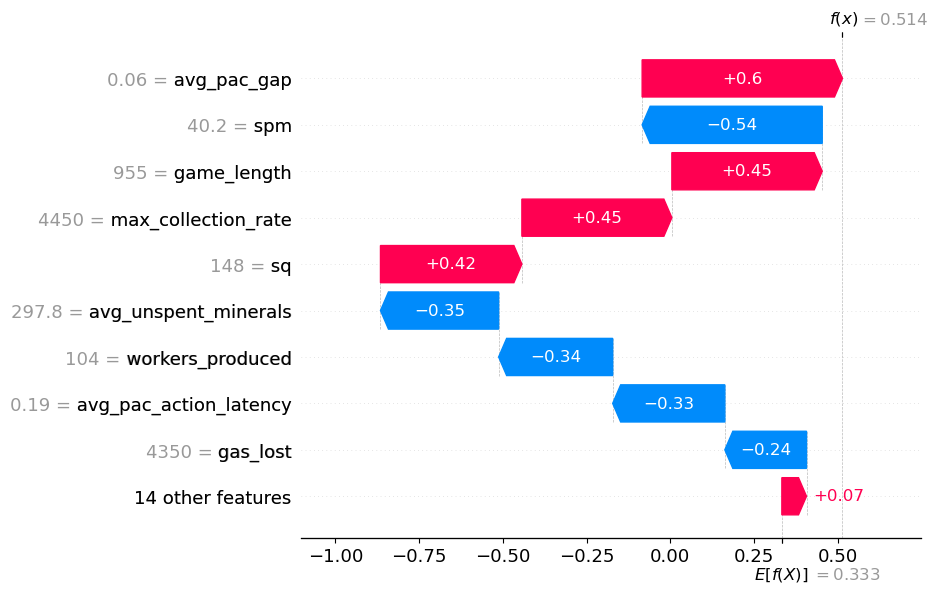

In [27]:
from shap import TreeExplainer, Explanation
from shap.plots import waterfall


sv = explainer(X.loc[[1156]])    # corrected, pass the row of interest as df
exp = Explanation(
    sv.values[:, :, 1],         # class to explain
    sv.base_values[:, 1],
    data=X.loc[[1156]].values,   # corrected, pass the row of interest as df
    feature_names=X.columns,
)
waterfall(exp[0]) 